# Import Statements

In [1]:
import pickle
import numpy as np
import pandas as pd
import scipy
import sklearn
import shap
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm as notebook_tqdm
import skopt
import copy

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import stats
from math import sqrt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [3]:
from platform import python_version

print(python_version())


3.10.12


In [4]:
print(np.__version__)

1.26.3


# Define all functions

In [21]:
#set the parameter space for XGBoost regression
space ={'learning_rate': Real(0.01, 1.0, 'log-uniform'),
        'min_child_weight': Integer(0, 10),
        'max_depth': Integer(0, 50),
        'max_delta_step': Integer(0, 20),
        'subsample': Real(0.01, 1.0, 'uniform'),
        'colsample_bytree': Real(0.01, 1.0, 'uniform'),
        'colsample_bylevel': Real(0.01, 1.0, 'uniform'),
        'reg_lambda': Real(1e-9, 1000, 'log-uniform'),
        'reg_alpha': Real(1e-9, 1.0, 'log-uniform'),
        'gamma': Real(1e-9, 0.5, 'log-uniform'),
        'n_estimators': Integer(50, 200),
        }

# set parameter space for LASSO

lasso_space = {
    'alpha': Real(1e-5, 1.0, 'log-uniform')  # L1 penalty term
}

In [22]:
#callback function to be used later which stops parameter search if it goes above 98% to save time
def on_step(optim_result):
    """
    Callback meant to view scores after
    each iteration while performing Bayesian
    Optimization in Skopt"""
    score = xgb_bayes_search.best_result_['score']
    print("best score: %s" % score)
    if score >= 0.98:
        print('Interrupting!')
        return True

In [23]:
#input training sets to find the best hyperparameters using Bayesian cross-validation for XGBoost model

def bayesian_xgb_search(X, y,space):
    """
    Perform Bayesian hyperparameter tuning for XGBoost using BayesSearchCV.

    Parameters:
        X_train (array-like): Training feature set.
        y_train (array-like): Training target variable.
        space (dict): Hyperparameter search space.

    Returns:
        xgb.XGBRegressor: Best XGBoost model with tuned parameters.
    """
    xgbreg = xgb.XGBRegressor(n_jobs=1)
    xgb_bayes_search = BayesSearchCV(
        xgbreg, space, n_iter=50, scoring=None, n_jobs=-1,
        cv=5, verbose=1, random_state=42, n_points=12
    )

    xgb_bayes_search.fit(X, y)
    
    print("Best XGB Parameters:", xgb_bayes_search.best_params_)
    
    best_params = xgb_bayes_search.best_params_
    best_xgbreg = xgb.XGBRegressor(**best_params)

    return best_xgbreg

#TO RUN - best_xgbreg = bayesian_xgb_search(X_train, y_train, space) 



def bayesian_lasso_search(X, y, lasso_space):
    lasso = Lasso(max_iter=100000)
    lasso_bayes_search = BayesSearchCV(
        estimator=lasso,
        search_spaces=lasso_space,
        scoring=None,
        cv=5,
        n_iter=10,  # number of iterations to try
        random_state=42,
        verbose=1,
        n_jobs=-1
)
    lasso_bayes_search.fit(X, y)
    
    print("Best Lasso hyperparameters:", lasso_bayes_search.best_params_)
    
    best_params = lasso_bayes_search.best_params_
    best_lasso = Lasso(**best_params)

    return best_lasso
    
#TO RUN - best_svreg = bayesian_svr_search(X_train, y_train, svr_space)

In [24]:
#input full sets except houldout to find the best model using k-fold (10) cross validation which uses the best hyperparametres from the previous step. 

def eval_k_fold(m, X, y, k):
    """
    Evaluates model using k-fold CV and returns the final model trained on full dataset.
    
    Parameters:
    m: model (e.g., XGBoost or RandomForest) with best hyperparameters
    X: feature matrix
    y: labels
    k: number of folds
    """
    cv = KFold(n_splits=k, shuffle=True)
    rmse_results = []
    percent_rmse_results = []
    r2_results = []
 
    low = 100
    best_fold_model = None
    
    for fold, (train, test) in enumerate(cv.split(X, y), start=1):
        print(f"\n=== Fold {fold} ===")
        
        m.fit(X[train], y[train].ravel())
        preds = m.predict(X[test])
        
        ss = sqrt(mean_squared_error(y[test], preds))  
        rr = r2_score(y[test], preds)                  
        mm = np.mean(y[test])
        error_mean = (ss / mm) * 100
        
        rmse_results.append(ss)
        percent_rmse_results.append(error_mean)
        r2_results.append(rr)
        
        print(f"R²: {rr:.4f}, RMSE: {ss:.4f}, %RMSE: {error_mean:.2f}")
        
        if error_mean < low:
            low = error_mean
            best_fold_model = copy.deepcopy(m)
    
    print("\nCV Summary:")
    print(f"Mean %RMSE: {np.mean(percent_rmse_results):.2f} ± {np.std(percent_rmse_results):.2f}")
    
    # Plot %RMSE per fold
    plt.figure(figsize=(8,5), dpi=300)
    cb_palette = ["#E69F00", "#56B4E9", "#009E73"]
    plt.plot(range(1, k+1), percent_rmse_results, marker="o", label="%RMSE", color=cb_palette[0])
    plt.plot(range(1, k+1), rmse_results, marker="s", label="RMSE", color=cb_palette[1])
    plt.plot(range(1, k+1), r2_results, marker="^", label="R²", color=cb_palette[2])
    plt.xlabel("Fold Number")
    plt.ylabel("Metric Value")
    plt.title("Cross-Validation Metrics per Fold")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Retrain the best model on full dataset
    final_model = copy.deepcopy(best_fold_model)
    final_model.fit(X, y.ravel())
    
    metrics = {
        "RMSE": rmse_results,
        "%RMSE": percent_rmse_results,
        "R2": r2_results
    }
    
    return final_model, metrics

#TO RUN - best_model_xgb, results = eval_k_fold(model, X, y, 10)

In [25]:
def plot_xgb_feature_importance(best_model, X_train, top_n=20, savepath=None):
    """
    Computes and plots the feature importance of an XGBoost model based on Gain.

    Parameters:
        best_model (XGBRegressor): Trained XGBoost model from Kfold cross validation.
        X_train (DataFrame): Training feature set used for Kfold CV.
        top_n (int): Number of top features to display. Default is 20.

    Returns:
        DataFrame: DataFrame containing feature importance scores.
    """
    # Generate feature names
    f_names = ['f' + str(i) for i in range(len(X_train.columns))]
    my_dict = best_model.get_booster().get_score(importance_type="gain")

    # Map feature names back to original column names
    new_dict = {X_train.columns[f_names.index(key)]: value for key, value in my_dict.items()}

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(new_dict, orient='index', columns=['F_Score(GAIN)'])

    # Select top N important features
    top_features = df.nlargest(top_n, "F_Score(GAIN)")

    # Plot feature importance
    fig = plt.figure(figsize=(8, 8), dpi=100)
    indexes = top_features.index[::-1]
    values = top_features.values.ravel()[::-1]

    plt.barh(indexes, values)
    plt.title(f'XGBoost Feature Importance for Top {top_n} SNPs')
    plt.ylabel('SNP Label')
    plt.xlabel('Relative F_Score (GAIN)')
    # Save at 600 dpi if path given
    if savepath is not None:
        fig.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()
    
    return df

#TO RUN - feature_importance= plot_xgb_feature_importance(best_model, X_train, top_n=20)

In [26]:
def evaluate_holdout_performance(best_model, X_holdout, y_holdout):
    """
    Evaluates the performance of a models on a holdout dataset.

    Parameters:
        best_model (XGBRegressor or RFR): Trained XGBoost/RF model from Kfold CV.
        X_holdout (DataFrame): Holdout feature set.
        y_holdout (Series or array): Holdout target values.

    Returns:
        dict: Dictionary containing RMSE, R2, and mean error percentage.
    """
    # Generate predictions
    all_preds = best_model.predict(X_holdout)

    # Compute performance metrics
    ss = sqrt(mean_squared_error(y_holdout, all_preds))
    rr = r2_score(y_holdout, all_preds)
    mm = np.mean(y_holdout)
    error_mean = (ss / mm) * 100
    
    # Print evaluation metrics
    print(f"R^2 Value of Holdout: {rr:.2f}")
    print(f"RMSE of Holdout: {ss:.2f}")
    print(f"Mean of Holdout: {mm:.2f}")
    print(f"This is {error_mean:.2f}% of the mean pheno data")
    
    # Prepare data for residual plot
    y_holdout = y_holdout.ravel()
    
    # Debug print first 5 examples
    for i in range(5):
        print(i, y_holdout[i], all_preds[i])
    
    # Create DataFrame for plotting
    thisplot = pd.DataFrame({
        'actual': y_holdout,
        'predicted': all_preds
    })
    
    # Generate regression plot
    plt.figure(figsize=(8, 6), dpi=300)
    sns.regplot(x="actual", y="predicted", data=thisplot, scatter_kws={'alpha': 0.5})
    plt.title('XGBoost Predicted vs Actual')
    plt.show()
    
    return {"RMSE": ss, "R2": rr, "Mean Error %": error_mean}

#TO RUN - metrics = evaluate_holdout_performance(best_model, X_holdout, y_holdout)

In [27]:
def plot_residuals(actual, predicted):
    """
    Plots residuals (Predicted - Actual) as a scatter plot.
    
    Parameters:
        actual (array-like): Array of actual values.
        predicted (array-like): Array of predicted values.
    """
    # Convert to NumPy arrays
    actual = np.array(actual)
    predicted = np.array(predicted)
    
    # Compute residuals (Predicted - Actual)
    residuals = predicted - actual
    
    # Create a scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
    plt.xlabel("Actual Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    # Show the plot
    plt.show()

#TO RUN - Plot_residuals(plot_x, plot_y)

# Load dataset

In [16]:
geno = pd.read_pickle("gene_pav_data.pkl")

In [17]:
geno.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,UWASoyPan05304,UWASoyPan05305,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314,UWASoyPan05315
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,0,0,1,0,0
AB-02,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,1,0,1,1,0,0
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,1,0,1,0,0,0
BR-02,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,1,0,1,0,0,0
BR-03,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,1,0,0,0,0,0


In [21]:
pheno =  pd.read_pickle("phenotype_yield_data.pkl")

In [22]:
pheno.head()

,Data-storage-ID,new_line,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,USB-756_SOYBEAN.EVALUATION.MS989,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,USB-014_SOYBEAN.EVALUATION.MN0102,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,USB-035_SOYBEAN.EVALUATION.MS2000_02,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,USB-499_SOYBEAN.EVALUATION.MS923,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,USB-393_SOYBEAN.EVALUATION.MN0102,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.15


In [23]:
pheno.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Data-storage-ID                  893 non-null    object 
 1   new_line                         893 non-null    object 
 2   SOYBEAN.EVALUATION.1IL64         893 non-null    int64  
 3   SOYBEAN.EVALUATION.1IL66         893 non-null    int64  
 4   SOYBEAN.EVALUATION.1MN63         893 non-null    int64  
 5   SOYBEAN.EVALUATION.2IL81.1       893 non-null    int64  
 6   SOYBEAN.EVALUATION.2IL81.2       893 non-null    int64  
 7   SOYBEAN.EVALUATION.2KY81         893 non-null    int64  
 8   SOYBEAN.EVALUATION.2MN81         893 non-null    int64  
 9   SOYBEAN.EVALUATION.3IL83.1       893 non-null    int64  
 10  SOYBEAN.EVALUATION.3IL83.2       893 non-null    int64  
 11  SOYBEAN.EVALUATION.3IL84         893 non-null    int64  
 12  SOYBEAN.EVALUATION.3MN

In [73]:
pheno = pheno.drop(['method_name', 'Origin'], axis=1)

In [32]:
Final_data = pd.merge(geno, pheno, on='Data-storage-ID', how='right', indicator=False)

In [33]:
Final_data.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.15


In [34]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Columns: 51448 entries, Data-storage-ID to observation_value
dtypes: float64(1), int64(31), object(51416)
memory usage: 350.5+ MB


In [27]:
Final_data = Final_data.drop(['new_line'], axis=1)

In [35]:
nan_values = Final_data[Final_data.isna().any(axis=1)] 

In [36]:
nan_values.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value


In [37]:
Final_data.to_pickle("Full_set_pav_yield_data.pkl") 

In [40]:
Final_data = pd.read_pickle("Full_set_pav_yield_data.pkl")
Final_data.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.15


In [38]:
#Final_data = Final_data.drop(['new_line'], axis=1)

In [41]:
#Final_data = Final_data.set_index("Data-storage-ID")
Final_data = Final_data.set_index("new_line")

In [42]:
Final_data.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
USB-756_SOYBEAN.EVALUATION.MS989,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0.08
USB-014_SOYBEAN.EVALUATION.MN0102,USB-014,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.09
USB-035_SOYBEAN.EVALUATION.MS2000_02,USB-035,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0.14
USB-499_SOYBEAN.EVALUATION.MS923,USB-499,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,1,0,0,0,0.15
USB-393_SOYBEAN.EVALUATION.MN0102,USB-393,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.15


In [43]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 893 entries, USB-756_SOYBEAN.EVALUATION.MS989 to HNY-58_SOYBEAN.EVALUATION.MS2011_12
Columns: 51447 entries, Data-storage-ID to observation_value
dtypes: float64(1), int64(31), object(51415)
memory usage: 350.5+ MB


In [44]:
#Split dataset into training,test and holdout

In [45]:
snps = Final_data.iloc[:, 1:51446]
snps.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
USB-756_SOYBEAN.EVALUATION.MS989,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1
USB-014_SOYBEAN.EVALUATION.MN0102,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-035_SOYBEAN.EVALUATION.MS2000_02,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
USB-499_SOYBEAN.EVALUATION.MS923,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,1,0,0,0
USB-393_SOYBEAN.EVALUATION.MN0102,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [47]:
yeild = Final_data.iloc[:, 51446:]
yeild.head()

,observation_value
new_line,
USB-756_SOYBEAN.EVALUATION.MS989,0.08
USB-014_SOYBEAN.EVALUATION.MN0102,0.09
USB-035_SOYBEAN.EVALUATION.MS2000_02,0.14
USB-499_SOYBEAN.EVALUATION.MS923,0.15
USB-393_SOYBEAN.EVALUATION.MN0102,0.15


In [48]:
X_full, X_holdout, y_full, y_holdout = train_test_split(snps, seed_oil, test_size=0.1, random_state=42, shuffle=True)

In [49]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 51445 entries, GlymaLee.01G000100.1.v1.1 to SOYBEAN.EVALUATION.MS989
dtypes: int64(31), object(51414)
memory usage: 315.2+ MB


In [50]:
X_full.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0


In [51]:
y_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   observation_value  803 non-null    float64
dtypes: float64(1)
memory usage: 12.5+ KB


In [52]:
y_full.head()

,observation_value
new_line,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1.06


In [53]:
#You have to kep new_line as index because the index needs to be unique while doing an outer merge, else the duplicated ones gets duplicated again
#training_data = pd.merge(X_full, y_full, on='Data-storage-ID', how='right', indicator=True)
training_data = pd.merge(X_full, y_full, on='new_line', how='right', indicator=False)

In [54]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 51446 entries, GlymaLee.01G000100.1.v1.1 to observation_value
dtypes: float64(1), int64(31), object(51414)
memory usage: 315.2+ MB


In [55]:
training_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [56]:
nan_values = Final_data[Final_data.isna().any(axis=1)] 

In [57]:
nan_values.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,


In [58]:
holdout_data = pd.merge(X_holdout, y_holdout, on='new_line', how='outer', indicator=False)

In [59]:
holdout_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, ESS_SOYBEAN.EVALUATION.MS1999_01 to USB-807_SOYBEAN.EVALUATION.MS2011_12
Columns: 51446 entries, GlymaLee.01G000100.1.v1.1 to observation_value
dtypes: float64(1), int64(31), object(51414)
memory usage: 35.3+ MB


In [60]:
training_data.to_pickle("gene_pav_yield_training_data.pkl")

In [61]:
holdout_data.to_pickle("gene_pav_yeild_holdout_data_pav.pkl")

# LASSO for feature selection

In [16]:
training_data = pd.read_pickle("gene_pav_training_data.pkl")

In [17]:
#Load file
training_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 51446 entries, GlymaLee.01G000100.1.v1.1 to observation_value
dtypes: float64(1), int64(31), object(51414)
memory usage: 315.2+ MB


In [18]:
training_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,0,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,1.06


In [19]:
#Extract only SNPs for feature selection

In [20]:
feature= training_data.iloc[:, 0:51414]
feature.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,UWASoyPan05304,UWASoyPan05305,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314,UWASoyPan05315
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,0,1,0,0,0
USB-127_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,1,0,0,0,0,0
USB-475_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,0
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,0,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,0,0,1,1,0
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,1,0,0,0,0,0


In [21]:
target = training_data["observation_value"]
target.head()

new_line
HNSM-03_SOYBEAN.EVALUATION.2KY81           1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01       2.47
USB-475_SOYBEAN.EVALUATION.1IL66           2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2      2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01    1.06
Name: observation_value, dtype: float64

In [22]:
cov = training_data.iloc[:,-32:]
cov.head()

,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,SOYBEAN.EVALUATION.3IL83.2,SOYBEAN.EVALUATION.3IL84,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.50
USB-127_SOYBEAN.EVALUATION.MS1999_01,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,2.47
USB-475_SOYBEAN.EVALUATION.1IL66,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.65
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,2.12
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1.06


In [23]:
X_train, X_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=42)

In [24]:
X_train.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,UWASoyPan05304,UWASoyPan05305,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314,UWASoyPan05315
new_line,,,,,,,,,,,,,,,,,,,,,
SRR1533451_SOYBEAN.EVALUATION.5IL90,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,1,0
USB-658_SOYBEAN.EVALUATION.IL945,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,0
HNSM-24_SOYBEAN.EVALUATION.2IL81.1,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,1,1,0,0,0,0
USB-460_SOYBEAN.EVALUATION.1IL66,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,1,0,0,1,0
USB-584_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,0,0,0,0,1,0


In [135]:
X_train_subset = X_train.iloc[:, :1000]
X_train_subset.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,Gm01_1784630,Gm01_1786373,Gm01_1788214,Gm01_1790690,Gm01_1790867,Gm01_1792041,Gm01_1792969,Gm01_1793822,Gm01_1794245,Gm01_1796361
new_line,,,,,,,,,,,,,,,,,,,,,
USB-201_SOYBEAN.CHEMICAL.NB.2009,0,1,0,1,0,0,0,0,0,1,...,2,2,0,0,0,0,0,2,0,0
USB-279_SOYBEAN.EVALUATION.MS2000_02,0,0,1,0,0,1,0,0,0,0,...,0,2,2,0,0,0,0,0,0,0
USB-117_SOYBEAN.EVALUATION.1IL66,0,0,0,1,0,0,0,0,0,0,...,2,2,0,0,0,0,0,2,0,0
HN053_WILD.SOYBEAN.EVAL.1IL85,0,0,0,0,1,0,0,0,0,0,...,0,2,2,0,0,0,0,0,0,0
USB-603_SOYBEAN.GENERAL,1,0,0,0,0,1,1,0,0,0,...,0,2,2,0,0,0,0,1,0,0


In [118]:
best_lasso = bayesian_lasso_search(X_train, y_train, lasso_space)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Lasso hyperparameters: OrderedDict([('alpha', 0.012172976749510152)])


In [25]:
# Create a Lasso Regression model with the best parameters from bayes CV
#alpha = 0.0468  # Regularization strength for full PAV (adjust from best_params)
alpha = 0.0122  # Regularization strength from var thresh dataset(adjust from best_params)
best_lasso_model = Lasso(alpha=alpha)

# Fit the model to the full training data
best_lasso_model.fit(feature, target)

Lasso(alpha=0.0122)

In [26]:
names=feature.columns
print("Column Names: {}".format(names.values))

Column Names: ['GlymaLee.01G000100.1.v1.1' 'GlymaLee.01G000200.1.v1.1'
 'GlymaLee.01G000300.1.v1.1' ... 'UWASoyPan05313' 'UWASoyPan05314'
 'UWASoyPan05315']


In [27]:
# Using np.abs() to make coefficients positive.  
lasso_coef = np.abs(best_lasso_model.coef_)

In [28]:
# Get boolean mask of selected features (non-zero coefficients)
selected_mask = lasso_coef != 0

In [29]:
# Subsetting the features which has more than 0.001 importance.
selected_feature=np.array(names)[selected_mask]
#print("Selected Feature Columns: {}".format(selected_feature))


In [30]:
#DONT have to do this as I will add all the covariates later
# Adding the target to the list of feaatures. 
#selected_feature=np.append(selected_feature, "BBD")
#print("Selected Columns: {}".format(selected_feature))

In [31]:
new_data = training_data[selected_feature]
print(new_data.head())

                                        GlymaLee.01G030900.1.v1.1  \
new_line                                                            
HNSM-03_SOYBEAN.EVALUATION.2KY81                                1   
USB-127_SOYBEAN.EVALUATION.MS1999_01                            0   
USB-475_SOYBEAN.EVALUATION.1IL66                                0   
SRR1533290_SOYBEAN.EVALUATION.3IL83.2                           1   
SRR1533220_SOYBEAN.EVALUATION.MS1999_01                         1   

                                        GlymaLee.01G044800.1.v1.1  \
new_line                                                            
HNSM-03_SOYBEAN.EVALUATION.2KY81                                1   
USB-127_SOYBEAN.EVALUATION.MS1999_01                            1   
USB-475_SOYBEAN.EVALUATION.1IL66                                1   
SRR1533290_SOYBEAN.EVALUATION.3IL83.2                           1   
SRR1533220_SOYBEAN.EVALUATION.MS1999_01                         1   

                                

In [32]:
new_data.head()

,GlymaLee.01G030900.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G022100.1.v1.1,GlymaLee.03G067500.1.v1.1,GlymaLee.05G034800.1.v1.1,GlymaLee.06G038900.1.v1.1,GlymaLee.06G241100.1.v1.1,GlymaLee.07G058300.1.v1.1,GlymaLee.07G060200.1.v1.1,...,UWASoyPan04151,UWASoyPan04225,UWASoyPan04548,UWASoyPan04637,UWASoyPan04675,UWASoyPan04725,UWASoyPan04939,UWASoyPan05007,UWASoyPan05034,UWASoyPan05310
new_line,,,,,,,,,,,,,,,,,,,,,
HNSM-03_SOYBEAN.EVALUATION.2KY81,1,1,0,0,1,1,1,1,1,1,...,0,0,0,0,1,1,0,0,1,1
USB-127_SOYBEAN.EVALUATION.MS1999_01,0,1,1,1,1,1,1,1,1,0,...,0,0,0,0,1,1,0,1,0,1
USB-475_SOYBEAN.EVALUATION.1IL66,0,1,0,1,1,1,1,1,1,0,...,1,0,0,0,1,1,0,0,0,1
SRR1533290_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,0,...,0,0,0,1,1,1,1,1,1,1
SRR1533220_SOYBEAN.EVALUATION.MS1999_01,1,1,0,0,1,1,1,0,1,0,...,1,0,0,0,1,1,0,0,1,1


In [33]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 171 entries, GlymaLee.01G030900.1.v1.1 to UWASoyPan05310
dtypes: object(171)
memory usage: 1.1+ MB


In [40]:
fs_data = pd.merge(new_data, cov, on='new_line', how='outer', indicator=False)
fs_data.head()

,GlymaLee.01G030900.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G022100.1.v1.1,GlymaLee.03G067500.1.v1.1,GlymaLee.05G034800.1.v1.1,GlymaLee.06G038900.1.v1.1,GlymaLee.06G241100.1.v1.1,GlymaLee.07G058300.1.v1.1,GlymaLee.07G060200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
new_line,,,,,,,,,,,,,,,,,,,,,
AB-01_SOYBEAN.EVALUATION.4IL87,1,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02_SOYBEAN.EVALUATION.MS2001_02,0,1,1,1,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1.30
BR-01_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14_SOYBEAN.EVALUATION.MS2011_12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [41]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, AB-01_SOYBEAN.EVALUATION.4IL87 to USB-818_SOYBEAN.EVALUATION.IL2011_12_13
Columns: 203 entries, GlymaLee.01G030900.1.v1.1 to observation_value
dtypes: float64(1), int64(31), object(171)
memory usage: 1.2+ MB


In [36]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,GlymaLee.01G030900.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G022100.1.v1.1,GlymaLee.03G067500.1.v1.1,GlymaLee.05G034800.1.v1.1,GlymaLee.06G038900.1.v1.1,GlymaLee.06G241100.1.v1.1,GlymaLee.07G058300.1.v1.1,GlymaLee.07G060200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1.54
AB-02,0,1,1,1,1,1,1,0,1,0,...,0,0,1,0,0,0,0,0,0,1.30
BR-01,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.33
BR-13,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,4.15
BR-14,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,1,0,0,0,0,2.87


In [42]:
fs_data.to_pickle("gene_pav_LASSO_yield_training_data.pkl")

# NO FS

In [14]:
fs_data = pd.read_pickle("gene_pav_training_data.pkl")

In [10]:
X = X_full.astype("int8")

In [15]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,1,1,1,1,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [16]:
X = fs_data

In [26]:
X_full= fs_data.iloc[:, 0:51447]

In [27]:
X_full.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-378,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-470,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533310,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [28]:
y_full = fs_data["seed_oil"]

In [29]:
y_full.head()

Data-storage-ID
HN076         15.4
USB-378       15.3
SRR1533285    21.3
USB-470       19.2
SRR1533310    17.8
Name: seed_oil, dtype: float64

In [30]:
X_all = X_full.values
y_all = y_full.values

In [31]:
X_dupe = fs_data.drop("seed_oil", axis=1)
X_dupe.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-378,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-470,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533310,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [32]:
X_dupe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076 to USB-514
Columns: 51447 entries, GlymaLee.01G000100.1.v1.1 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(33), object(51414)
memory usage: 449.0+ MB


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

In [34]:
X_train.shape

(1029, 51447)

In [ ]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [23]:
best_xgbr_model = eval_k_fold(best_xgbreg, X_all, y_all, 10)

fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7002761770525592
RMSE for dataset is:1.4233311583346406& mean of this fold is 18.218260869565217
this is 7.812662078587356% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.6898926299605794
RMSE for dataset is:1.6534487366536528& mean of this fold is 17.803478260869564
this is 9.287223049485693% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.745057079046642
RMSE for dataset is:1.387724777674506& mean of this fold is 17.115652173913045
this is 8.107928132528993% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7304756815913054
RMSE for dataset is:1.6453964032071529& mean of this fold is 17.172173913043476
this is 9.581759487989801% of the mean pheno data
fitting done. Processing fold accuracy + checking best model
R^2 Value is: 0.7796226299480032
RMSE for dat

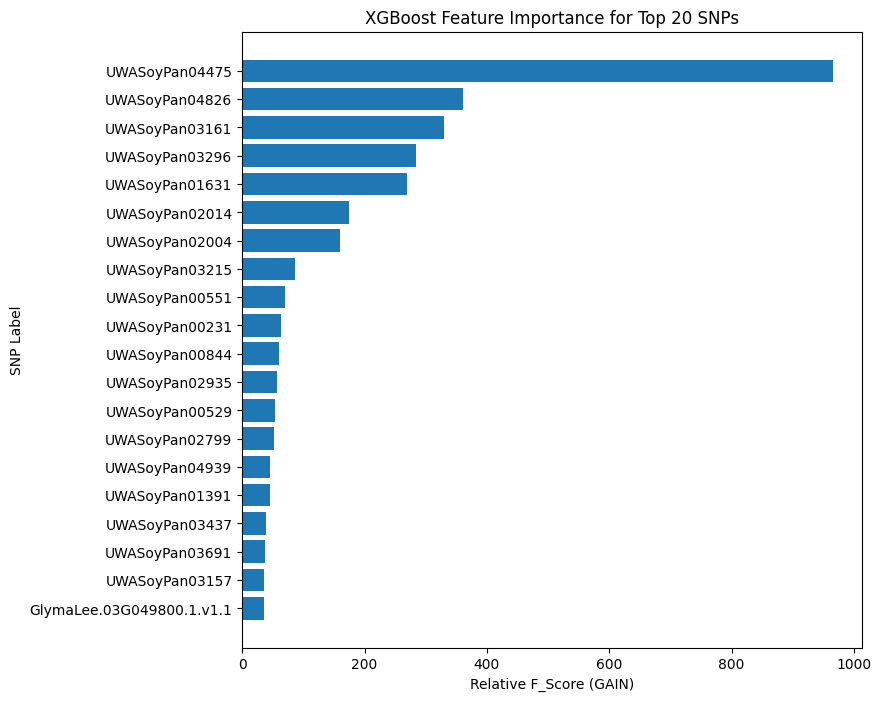

In [24]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_full, top_n=20)

In [25]:
explainer = shap.Explainer(best_xgbr_model)

In [26]:
shap_values = explainer(X)

<Axes: xlabel='SHAP value (impact on model output)'>

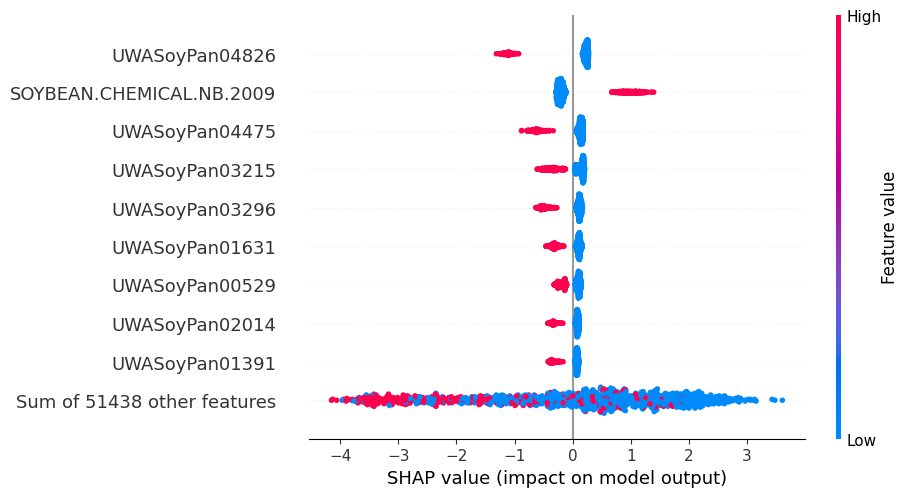

In [27]:
shap.plots.beeswarm(shap_values, show=False)

In [28]:
X_holdout = pd.read_pickle("x_holdout_pav.pkl")
X_holdout.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN015,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HNEX-04,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HNSM-12,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533429,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-480,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [29]:
y_holdout = pd.read_pickle("y_holdout_pav.pkl")
y_holdout.head()

,seed_oil
Data-storage-ID,
HN015,15.0
HNEX-04,20.3
HNSM-12,18.9
SRR1533429,22.4
USB-480,18.2


In [80]:
holdout_data = holdout_data.set_index('Data-storage-ID')

In [85]:
holdout_data.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,16.8
HN010,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,18.3
HN015,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,15.0
HN017B,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,15.5
HN023,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,15.6


In [86]:
X_holdout = holdout_data.iloc[:, 0:538334]
X_holdout.head()

,Gm01_3567,Gm01_3677,Gm01_7345,Gm01_7357,Gm01_8865,Gm01_8876,Gm01_10496,Gm01_11433,Gm01_13491,Gm01_15043,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,0,0,1,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
HN010,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HN015,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN023,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [87]:
y_holdout = holdout_data.iloc[:, 538334:]
y_holdout.head()

,seed_oil
Data-storage-ID,
HN009,16.8
HN010,18.3
HN015,15.0
HN017B,15.5
HN023,15.6


In [88]:
X_dupe.head()

,Gm01_782148,Gm01_1381480,Gm01_2611788,Gm01_4432828,Gm01_7137165,Gm01_7544276,Gm01_8931835,Gm01_34025243,Gm01_46985479,Gm01_47028050,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
AB-02,2,0,0,0,2,2,2,0,0,0,...,0,0,1,0,0,0,0,0,0,0
BR-24,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0
ESS,0,2,0,0,0,0,0,2,2,2,...,0,0,0,0,0,0,0,0,0,0


In [89]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [90]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, HN009 to USB-803
Columns: 277 entries, Gm01_782148 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(277)
memory usage: 278.0+ KB


In [91]:
y_holdout.shape

(128, 1)

In [30]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.81
RMSE of Holdout: 1.44
Mean of Holdout: 16.91
This is 8.51% of the mean pheno data
0 15.0 16.02569
1 20.3 20.61507
2 18.9 19.482779
3 22.4 20.939512
4 18.2 18.523626
5 6.8 10.695093


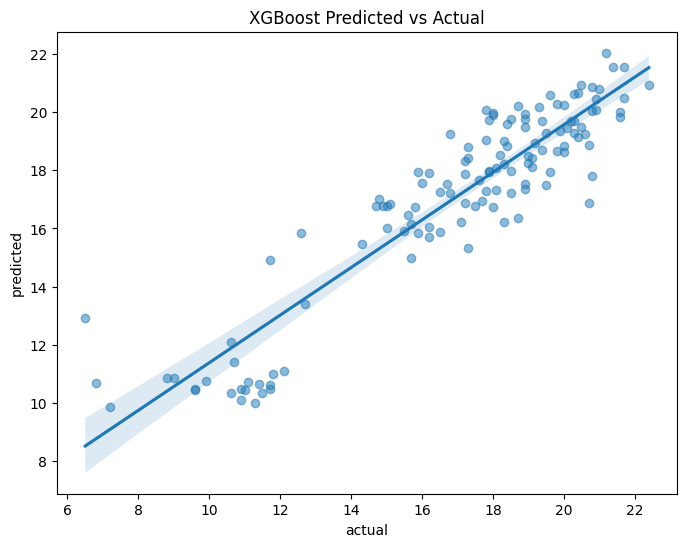

In [31]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

In [32]:
pickle.dump(best_xgbr_model, open("xgbr_pav_fullset_seedoil.pickle.dat", "wb"))

# LASSO

In [5]:
fs_data = pd.read_pickle("gene_pav_LASSO_training_data.pkl")

In [6]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,1,1,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [7]:
fs_data.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,17.6
AB-02,1,1,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,16.8
BR-24,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,20.6
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,20.9
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.6


In [8]:
X_full= fs_data.iloc[:, 0:187]

In [9]:
X_full.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
AB-02,1,1,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
BR-24,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01 to USB-807
Columns: 187 entries, GlymaLee.02G163600.1.v1.1 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(33), object(154)
memory usage: 1.6+ MB


In [11]:
object_cols = X_full.select_dtypes(include='object').columns
print(object_cols)

Index(['GlymaLee.02G163600.1.v1.1', 'GlymaLee.03G021800.1.v1.1',
       'GlymaLee.03G036400.1.v1.1', 'GlymaLee.05G083000.1.v1.1',
       'GlymaLee.07G051800.1.v1.1', 'GlymaLee.07G090500.1.v1.1',
       'GlymaLee.08G248800.1.v1.1', 'GlymaLee.08G248900.1.v1.1',
       'GlymaLee.09G124600.1.v1.1', 'GlymaLee.10G105000.1.v1.1',
       ...
       'UWASoyPan04583', 'UWASoyPan04676', 'UWASoyPan04725', 'UWASoyPan04826',
       'UWASoyPan04939', 'UWASoyPan04983', 'UWASoyPan05125', 'UWASoyPan05133',
       'UWASoyPan05144', 'UWASoyPan05256'],
      dtype='object', length=154)


In [12]:
X= X_full.astype("int8")

In [13]:
X_dupe= X_full.astype("int8")

In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, AB-01 to USB-807
Columns: 187 entries, GlymaLee.02G163600.1.v1.1 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int8(187)
memory usage: 217.9+ KB


In [15]:
X.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,0,1,1,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
AB-02,1,1,1,0,1,1,1,1,1,1,...,0,0,1,0,0,0,0,0,0,0
BR-24,1,1,1,1,1,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
ESS,1,1,1,0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [16]:
y_full = fs_data["seed_oil"].values

In [17]:
# Split training set into training and validation

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y_full, test_size=0.1, random_state=42)

In [30]:
X_train = X_train.to_numpy()
#y_train = y_train.to_numpy()

In [31]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 1.0), ('colsample_bytree', 1.0), ('gamma', 1.9640809084105368e-08), ('learning_rate', 0.5763640574502483), ('max_delta_step', 0), ('max_depth', 33), ('min_child_weight', 6), ('n_estimators', 200), ('reg_alpha', 1e-09), ('reg_lambda', 1000.0), ('subsample', 1.0)])



=== Fold 1 ===
R²: 0.8278, RMSE: 1.4493, %RMSE: 8.44

=== Fold 2 ===
R²: 0.8149, RMSE: 1.4948, %RMSE: 8.84

=== Fold 3 ===
R²: 0.7633, RMSE: 1.6781, %RMSE: 9.36

=== Fold 4 ===
R²: 0.7831, RMSE: 1.5869, %RMSE: 8.96

=== Fold 5 ===
R²: 0.8109, RMSE: 1.5449, %RMSE: 9.15

=== Fold 6 ===
R²: 0.7302, RMSE: 1.5692, %RMSE: 8.69

=== Fold 7 ===
R²: 0.7919, RMSE: 1.6690, %RMSE: 9.80

=== Fold 8 ===
R²: 0.8158, RMSE: 1.5080, %RMSE: 8.60

=== Fold 9 ===
R²: 0.7553, RMSE: 1.7030, %RMSE: 9.94

=== Fold 10 ===
R²: 0.8546, RMSE: 1.3490, %RMSE: 7.86

CV Summary:
Mean %RMSE: 8.96 ± 0.60


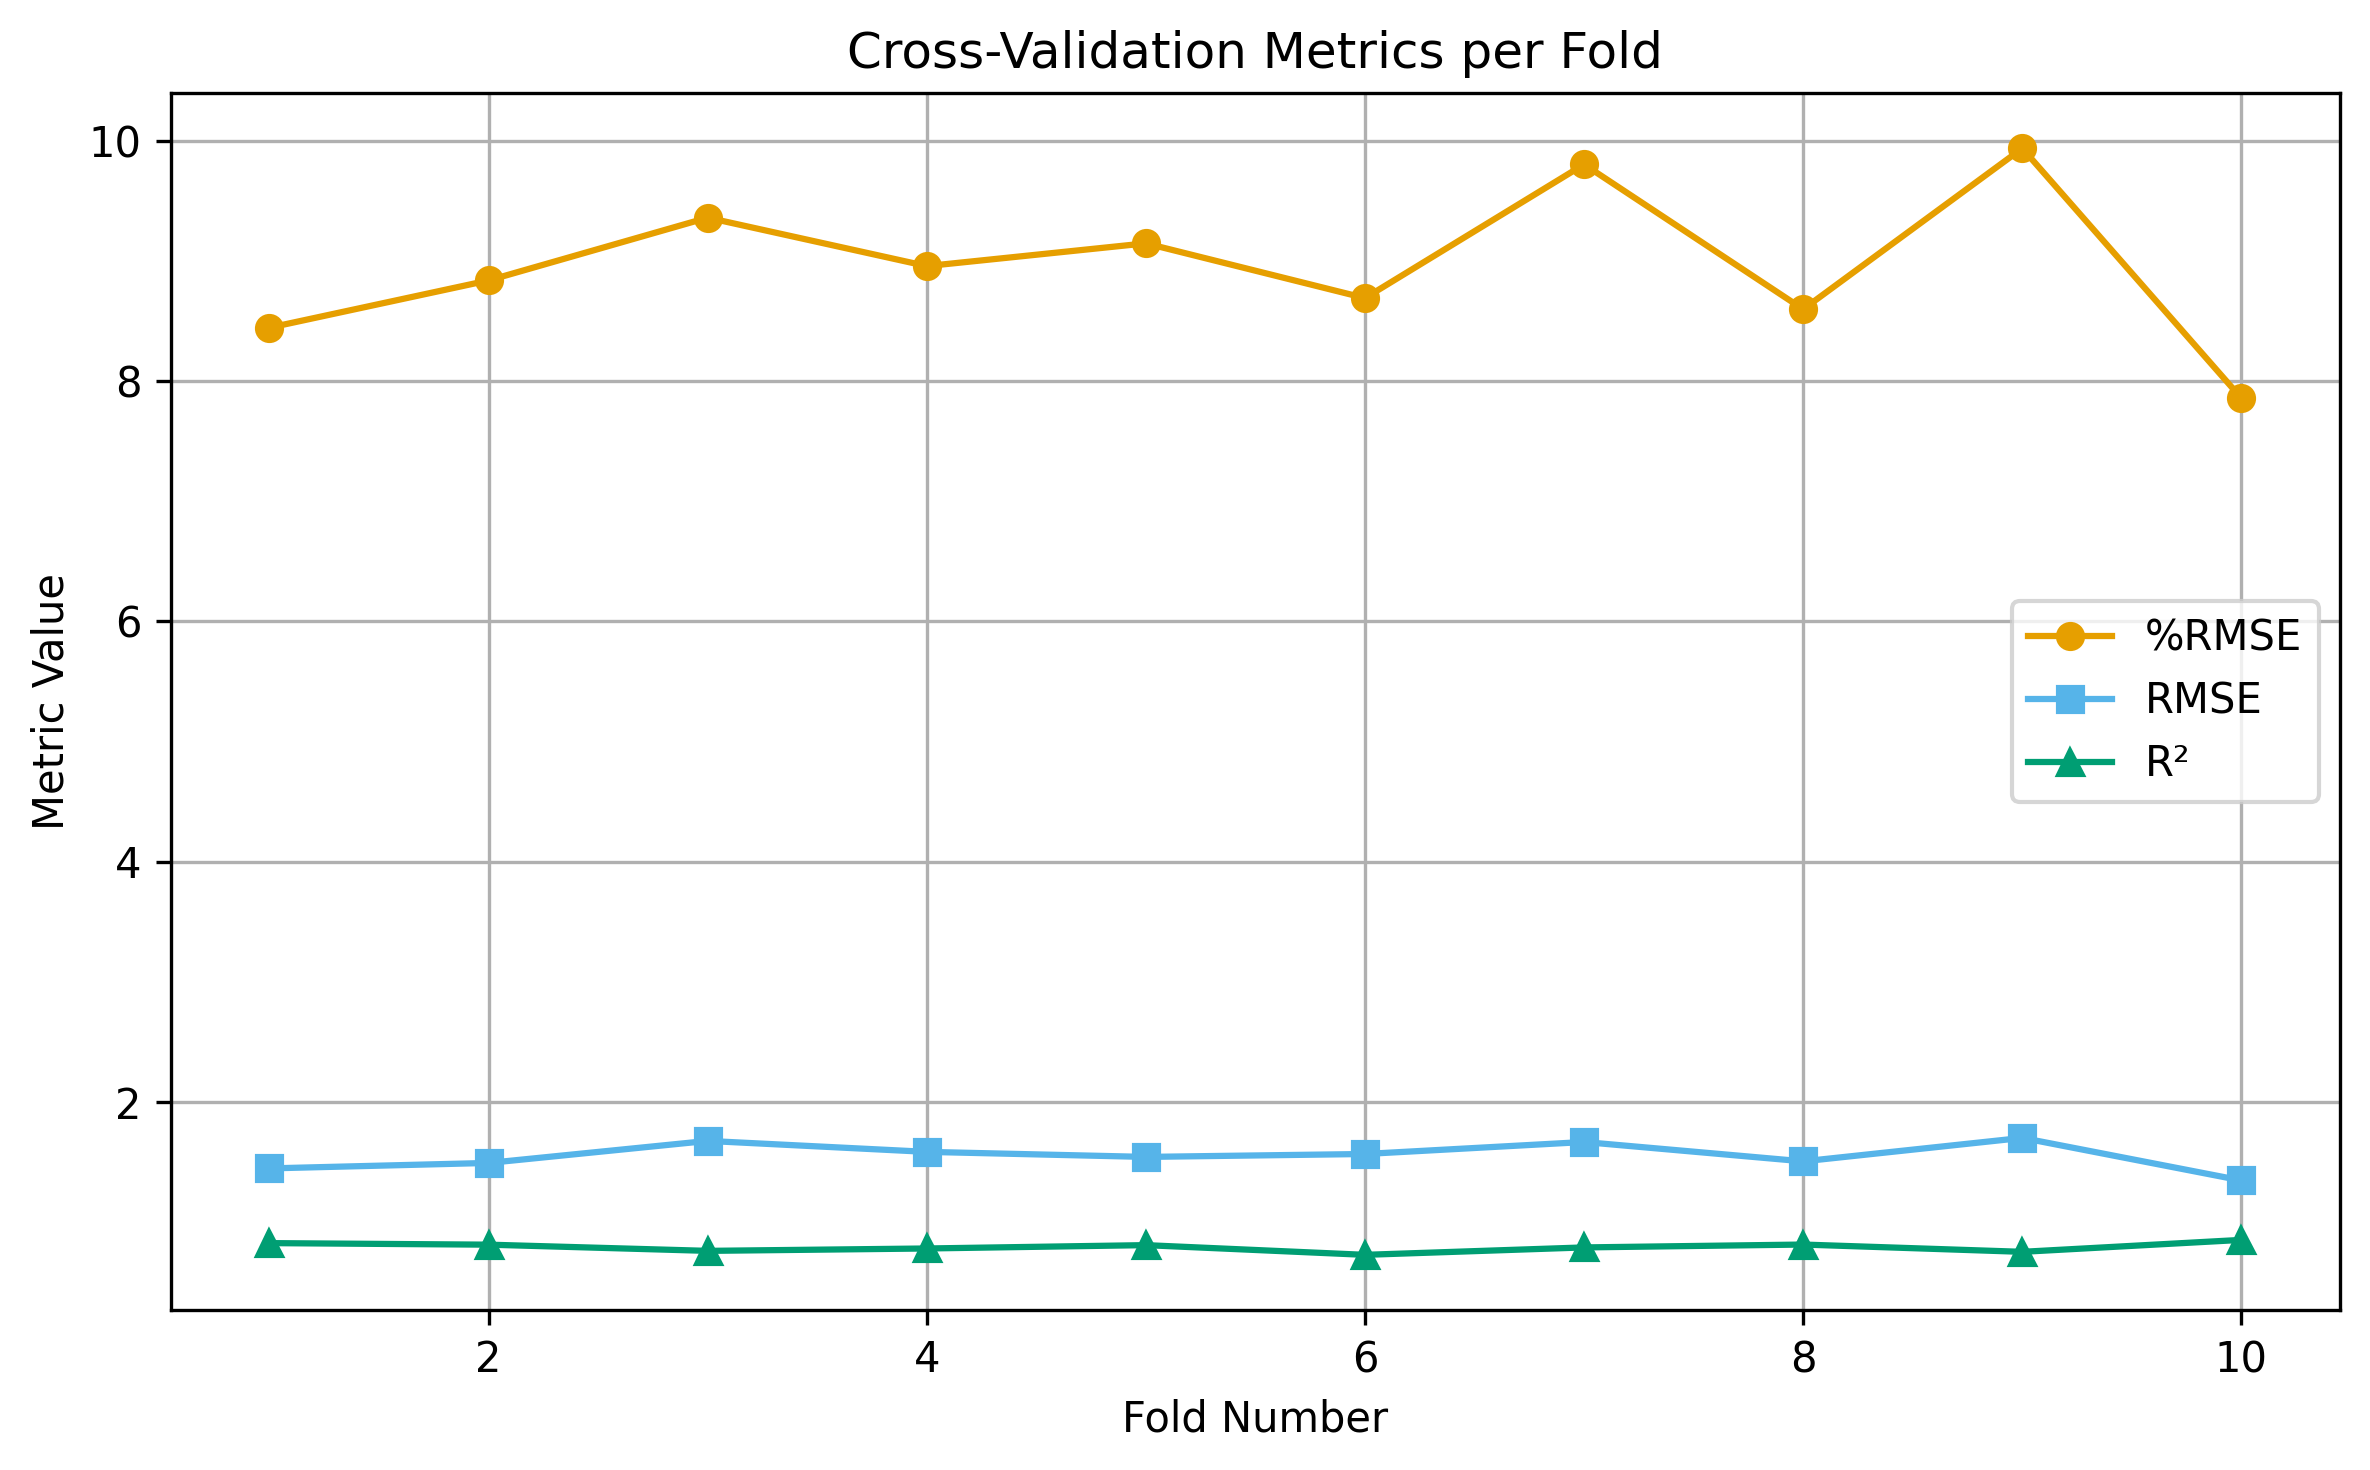

In [33]:
#X = X.to_numpy()
#y_full = y_full.to_numpy()
best_xgbr_model, results = eval_k_fold(best_xgbreg, X, y_full, 10)

In [19]:
#pickle.dump(best_xgbr_model, open("gene_pav_LASSO.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("best_models/gene_pav_LASSO.pickle.dat", "rb"))

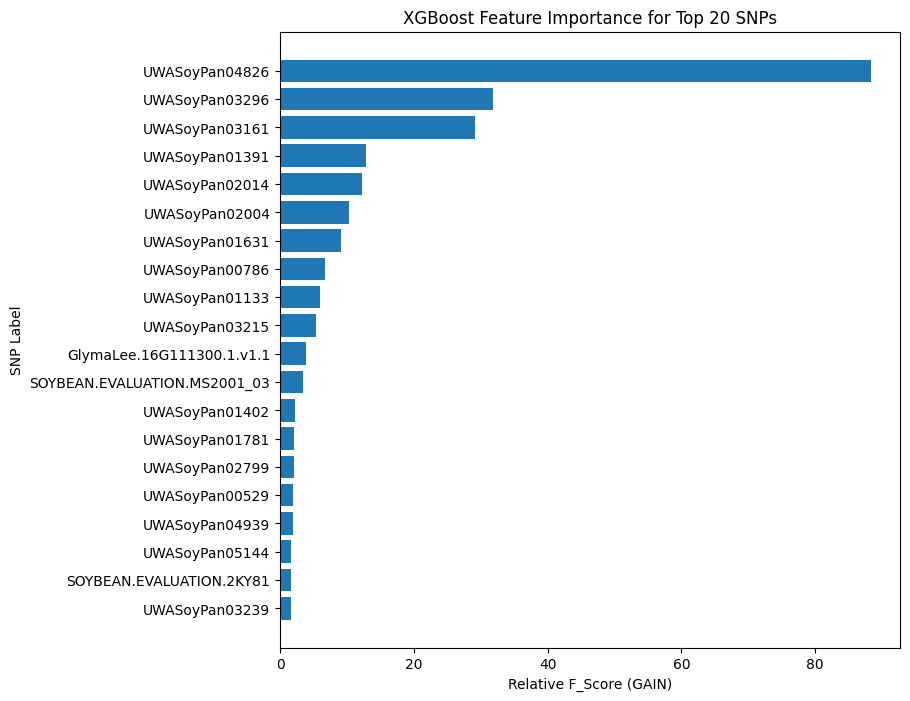

In [28]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, X_full, top_n=20, savepath="PAV_lasso_so_FI.png")

In [29]:
explainer = shap.Explainer(best_xgbr_model)

In [30]:
shap_values = explainer(X_dupe, check_additivity=False)

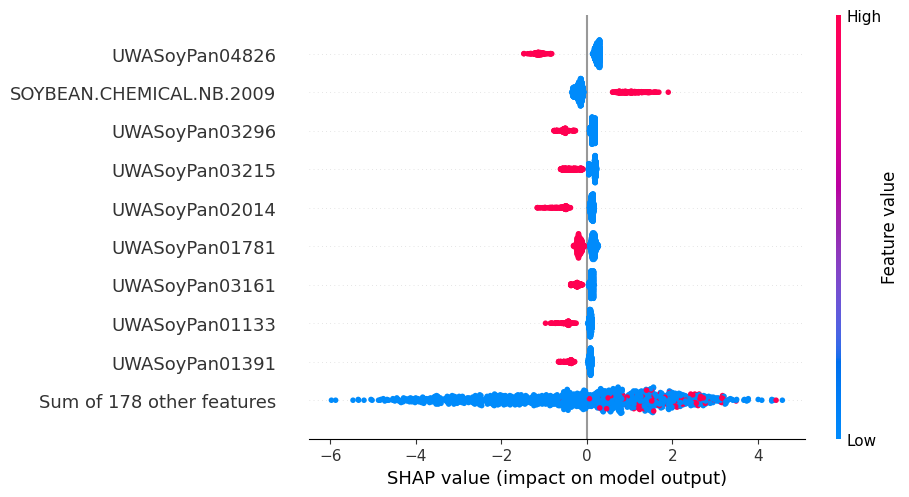

In [31]:
shap.plots.beeswarm(shap_values, show=False)
plt.savefig('PAV_lasso_so_shap.png', dpi=600, bbox_inches='tight')

In [44]:
holdout_data = pd.read_pickle("gene_pav_holdout_data_pav.pkl")
holdout_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.6


In [45]:
holdout_data['Data-storage-ID'] = holdout_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
holdout_data = holdout_data.reset_index(drop=True).set_index('Data-storage-ID')
holdout_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,16.8
HN010,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.0
HN017B,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.6


In [48]:
X_holdout = holdout_data.iloc[:, 0:51447]
X_holdout.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G000200.1.v1.1,GlymaLee.01G000300.1.v1.1,GlymaLee.01G000400.1.v1.1,GlymaLee.01G000500.1.v1.1,GlymaLee.01G000600.1.v1.1,GlymaLee.01G000700.1.v1.1,GlymaLee.01G000800.1.v1.1,GlymaLee.01G000900.1.v1.1,GlymaLee.01G001000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN010,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN015,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN017B,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN023,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [49]:
y_holdout = holdout_data.iloc[:, 51447:]
y_holdout.head()

,seed_oil
Data-storage-ID,
HN009,16.8
HN010,18.3
HN015,15.0
HN017B,15.5
HN023,15.6


In [50]:
# Ensure both trainjg and holdout datasets have the same columns
X_full, X_holdout = X_full.align(X_holdout, join='inner', axis=1)

In [52]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, HN009 to USB-803
Columns: 187 entries, GlymaLee.02G163600.1.v1.1 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(33), object(154)
memory usage: 188.0+ KB


In [53]:
X_holdout.head()

,GlymaLee.02G163600.1.v1.1,GlymaLee.03G021800.1.v1.1,GlymaLee.03G036400.1.v1.1,GlymaLee.05G083000.1.v1.1,GlymaLee.07G051800.1.v1.1,GlymaLee.07G090500.1.v1.1,GlymaLee.08G248800.1.v1.1,GlymaLee.08G248900.1.v1.1,GlymaLee.09G124600.1.v1.1,GlymaLee.10G105000.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN010,1,1,1,0,0,1,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN015,0,1,1,0,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN017B,0,0,1,0,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
HN023,1,0,1,0,1,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [54]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.86
RMSE of Holdout: 1.37
Mean of Holdout: 16.91
This is 8.11% of the mean pheno data
0 16.8 19.326368
1 18.3 15.659411
2 15.0 14.937352
3 15.5 15.581572
4 15.6 16.197126


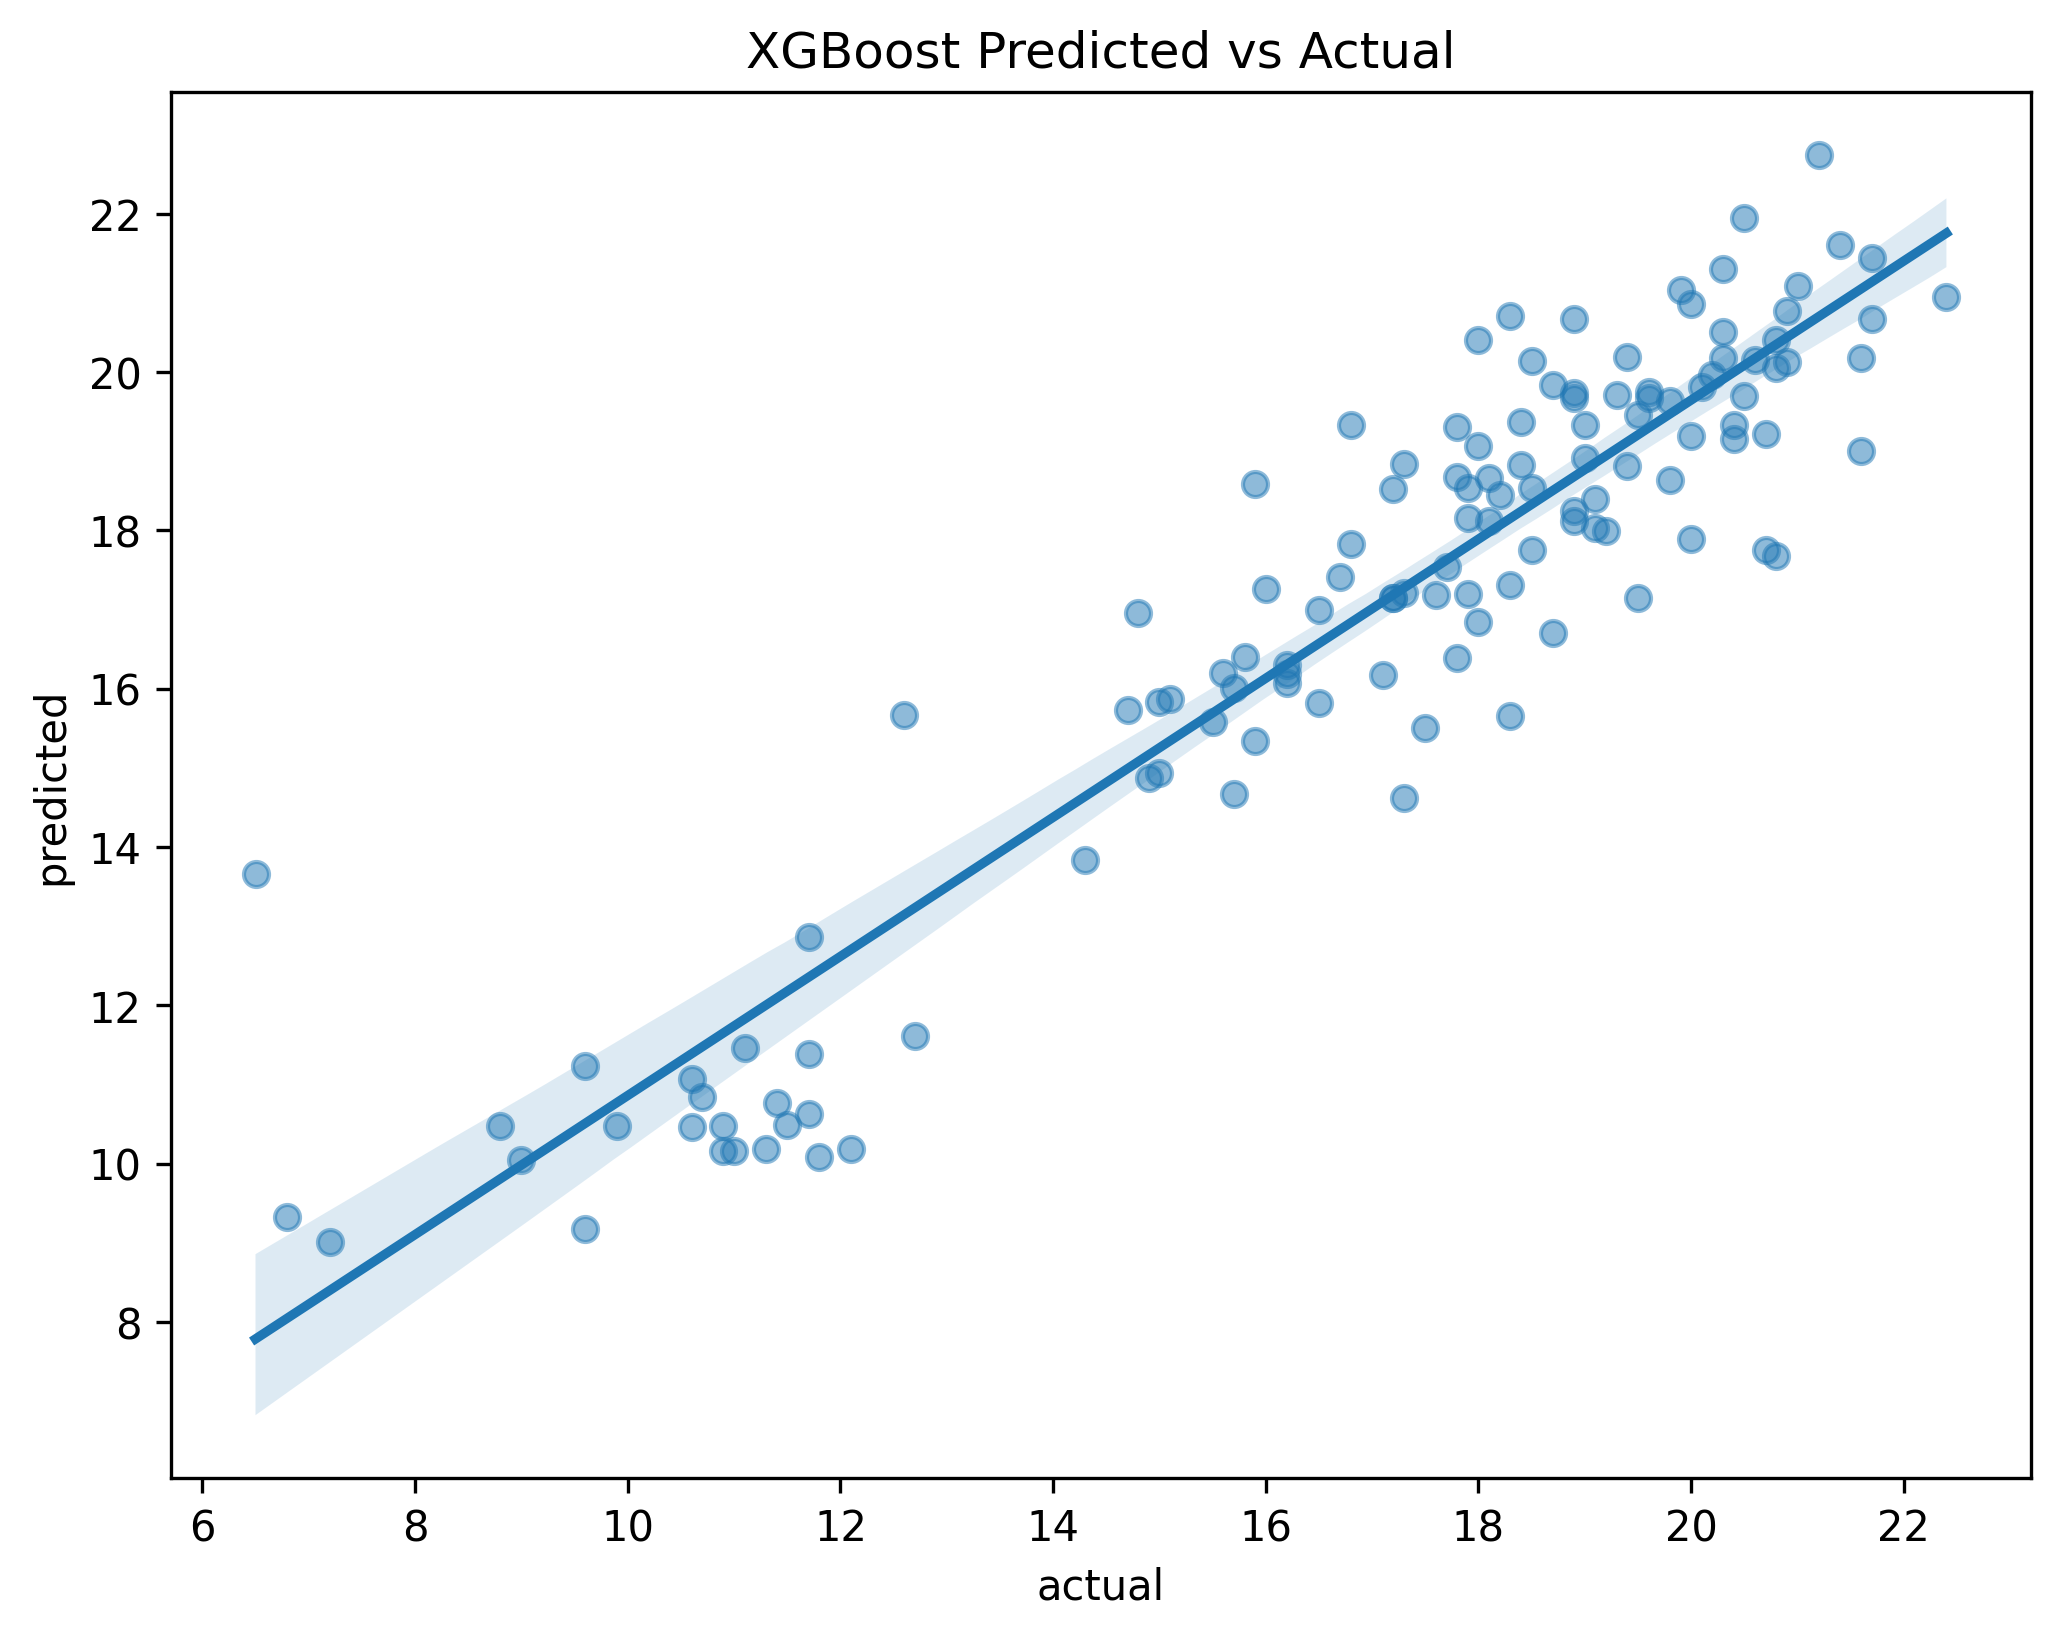

In [56]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)

Text(0.5, 1.0, 'Residual Plot')

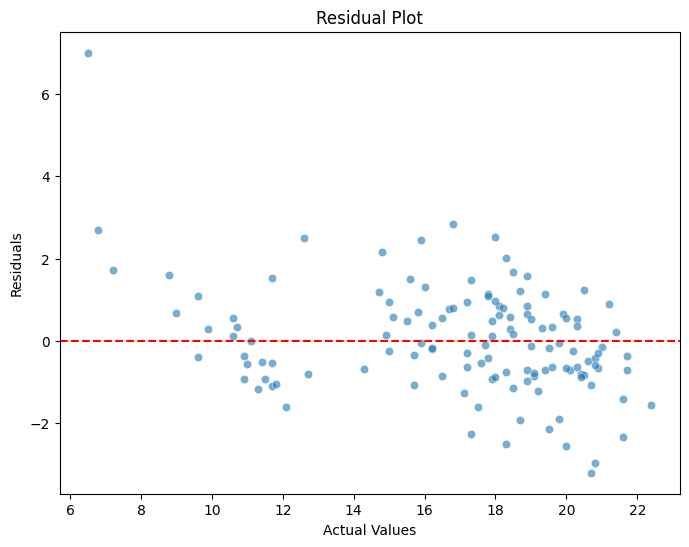

In [92]:
actual = np.array(plot_x)
predicted = np.array(plot_y)
    
# Compute residuals (Predicted - Actual)
residuals = predicted - actual
    
# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)
    
    # Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='red', linestyle='--')
    
    # Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
    
    # Show the plot


# Variance Threshold

In [83]:
geno = pd.read_pickle("gene_pav_afterFS_varthreshold.pkl")

In [86]:
geno.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,UWASoyPan05256,UWASoyPan05261,UWASoyPan05301,UWASoyPan05306,UWASoyPan05309,UWASoyPan05310,UWASoyPan05311,UWASoyPan05312,UWASoyPan05313,UWASoyPan05314
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
AB-01,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,1,1,0,0,1,0
AB-02,1,0,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,0,1,1,0
BR-01,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,0,1,0,0
BR-02,1,1,1,1,1,1,1,1,1,1,...,0,0,1,1,0,1,0,1,0,0
BR-03,1,1,1,1,1,1,1,1,1,1,...,1,0,1,1,0,1,0,0,0,0


In [84]:
pheno =  pd.read_pickle("phenotype_yield_data.pkl")

In [85]:
pheno.head()

,Data-storage-ID,new_line,SOYBEAN.EVALUATION.1IL64,SOYBEAN.EVALUATION.1IL66,SOYBEAN.EVALUATION.1MN63,SOYBEAN.EVALUATION.2IL81.1,SOYBEAN.EVALUATION.2IL81.2,SOYBEAN.EVALUATION.2KY81,SOYBEAN.EVALUATION.2MN81,SOYBEAN.EVALUATION.3IL83.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,USB-756_SOYBEAN.EVALUATION.MS989,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,USB-014_SOYBEAN.EVALUATION.MN0102,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,USB-035_SOYBEAN.EVALUATION.MS2000_02,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,USB-499_SOYBEAN.EVALUATION.MS923,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,USB-393_SOYBEAN.EVALUATION.MN0102,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.15


In [87]:
Final_data = pd.merge(geno, pheno, on='Data-storage-ID', how='right', indicator=False)

In [88]:
Final_data.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value
0,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,1,0.08
1,USB-014,1,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0.09
2,USB-035,1,0,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0.14
3,USB-499,1,1,1,0,1,0,1,1,0,...,0,0,0,0,0,1,0,0,0,0.15
4,USB-393,1,1,1,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0.15


In [89]:
Final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Columns: 2952 entries, Data-storage-ID to observation_value
dtypes: float64(1), int64(31), object(2920)
memory usage: 20.1+ MB


In [90]:
nan_values = Final_data[Final_data.isna().any(axis=1)] 

In [91]:
nan_values.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,observation_value


In [95]:
Final_data.set_index('new_line', inplace=True)

In [100]:
snps = Final_data.iloc[:, 0:2950]
snps.head()

,Data-storage-ID,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,...,SOYBEAN.EVALUATION.MN945,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS2011_12,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989
new_line,,,,,,,,,,,,,,,,,,,,,
USB-756_SOYBEAN.EVALUATION.MS989,USB-756,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,1
USB-014_SOYBEAN.EVALUATION.MN0102,USB-014,1,0,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-035_SOYBEAN.EVALUATION.MS2000_02,USB-035,1,0,1,1,1,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
USB-499_SOYBEAN.EVALUATION.MS923,USB-499,1,1,1,0,1,0,1,1,0,...,0,0,0,0,0,0,1,0,0,0
USB-393_SOYBEAN.EVALUATION.MN0102,USB-393,1,1,1,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [101]:
yeild = Final_data.iloc[:, 2950:]
yeild.head()

,observation_value
new_line,
USB-756_SOYBEAN.EVALUATION.MS989,0.08
USB-014_SOYBEAN.EVALUATION.MN0102,0.09
USB-035_SOYBEAN.EVALUATION.MS2000_02,0.14
USB-499_SOYBEAN.EVALUATION.MS923,0.15
USB-393_SOYBEAN.EVALUATION.MN0102,0.15


In [102]:
X_full, X_holdout, y_full, y_holdout = train_test_split(snps, yeild, test_size=0.1, random_state=42, shuffle=True)

In [103]:
X_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 803 entries, HNSM-03_SOYBEAN.EVALUATION.2KY81 to USB-752_SOYBEAN.EVALUATION.MS989
Columns: 2950 entries, Data-storage-ID to SOYBEAN.EVALUATION.MS989
dtypes: int64(31), object(2919)
memory usage: 18.1+ MB


In [104]:
training_data = pd.merge(X_full, y_full, on='new_line', how='outer', indicator=False)

In [105]:
holdout_data = pd.merge(X_holdout, y_holdout, on='new_line', how='outer', indicator=False)

In [106]:
training_data.to_pickle("gene_pav_afterFS_varthreshold_yield_training_data.pkl")

In [107]:
holdout_data.to_pickle("gene_pav_afterFS_varthreshold_yield_holdout_data_pav.pkl")

# Run Models

In [32]:
fs_data = pd.read_pickle("gene_pav_afterFS_varthreshold_training_data.pkl")

In [33]:
fs_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN076_SOYBEAN.CHEMICAL.NB.2009,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378_SOYBEAN.EVALUATION.MS2001_02,1,0,1,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285_SOYBEAN.CHEMICAL.NB.2009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470_SOYBEAN.EVALUATION.1IL66,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310_SOYBEAN.EVALUATION.2IL81.1,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [34]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076_SOYBEAN.CHEMICAL.NB.2009 to USB-514_SOYBEAN.GENERAL
Columns: 2952 entries, GlymaLee.01G000100.1.v1.1 to seed_oil
dtypes: float64(1), int64(33), object(2918)
memory usage: 25.8+ MB


In [35]:
fs_data['Data-storage-ID'] = fs_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
fs_data = fs_data.reset_index(drop=True).set_index('Data-storage-ID')
fs_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.4
USB-378,1,0,1,1,1,1,1,1,1,0,...,0,1,0,0,0,0,0,0,0,15.3
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,21.3
USB-470,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,19.2
SRR1533310,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,17.8


In [36]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076 to USB-514
Columns: 2952 entries, GlymaLee.01G000100.1.v1.1 to seed_oil
dtypes: float64(1), int64(33), object(2918)
memory usage: 25.8+ MB


In [37]:
only_snps = fs_data.iloc[:, 0:2951]
only_snps.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN076,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
USB-378,1,0,1,1,1,1,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
SRR1533285,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
USB-470,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
SRR1533310,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [38]:
only_snps = only_snps.astype("int8")
only_snps.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1144 entries, HN076 to USB-514
Columns: 2951 entries, GlymaLee.01G000100.1.v1.1 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int8(2951)
memory usage: 3.2+ MB


In [39]:
only_snps_dupe = only_snps

In [40]:
y_all = fs_data["seed_oil"]
y_all.head()

Data-storage-ID
HN076         15.4
USB-378       15.3
SRR1533285    21.3
USB-470       19.2
SRR1533310    17.8
Name: seed_oil, dtype: float64

### Run models

In [41]:
X_train, X_test, y_train, y_test = train_test_split(only_snps, y_all, test_size=0.1, random_state=42)

In [112]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

In [113]:
best_xgbreg = bayesian_xgb_search(X_train, y_train, space)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best XGB Parameters: OrderedDict([('colsample_bylevel', 0.6093561197609833), ('colsample_bytree', 0.8584066342158617), ('gamma', 2.260579253768497e-05), ('learning_rate', 0.01690316271516304), ('max_delta_step', 10), ('max_depth', 22), ('min_child_weight', 2), ('n_estimators', 193), ('reg_alpha', 8.80522322948005e-09), ('reg_lambda', 1.197248667442437e-05), ('subsample', 0.25978022854064087)])



=== Fold 1 ===
R²: 0.7879, RMSE: 1.5573, %RMSE: 8.85

=== Fold 2 ===
R²: 0.7642, RMSE: 1.7583, %RMSE: 10.31

=== Fold 3 ===
R²: 0.7583, RMSE: 1.6672, %RMSE: 9.41

=== Fold 4 ===
R²: 0.6837, RMSE: 2.0165, %RMSE: 11.76

=== Fold 5 ===
R²: 0.7901, RMSE: 1.5568, %RMSE: 8.96

=== Fold 6 ===
R²: 0.8070, RMSE: 1.7003, %RMSE: 9.81

=== Fold 7 ===
R²: 0.7280, RMSE: 1.7716, %RMSE: 10.34

=== Fold 8 ===
R²: 0.7715, RMSE: 1.7142, %RMSE: 9.69

=== Fold 9 ===
R²: 0.7631, RMSE: 1.5565, %RMSE: 9.10

=== Fold 10 ===
R²: 0.6978, RMSE: 1.7928, %RMSE: 10.28

CV Summary:
Mean %RMSE: 9.85 ± 0.83


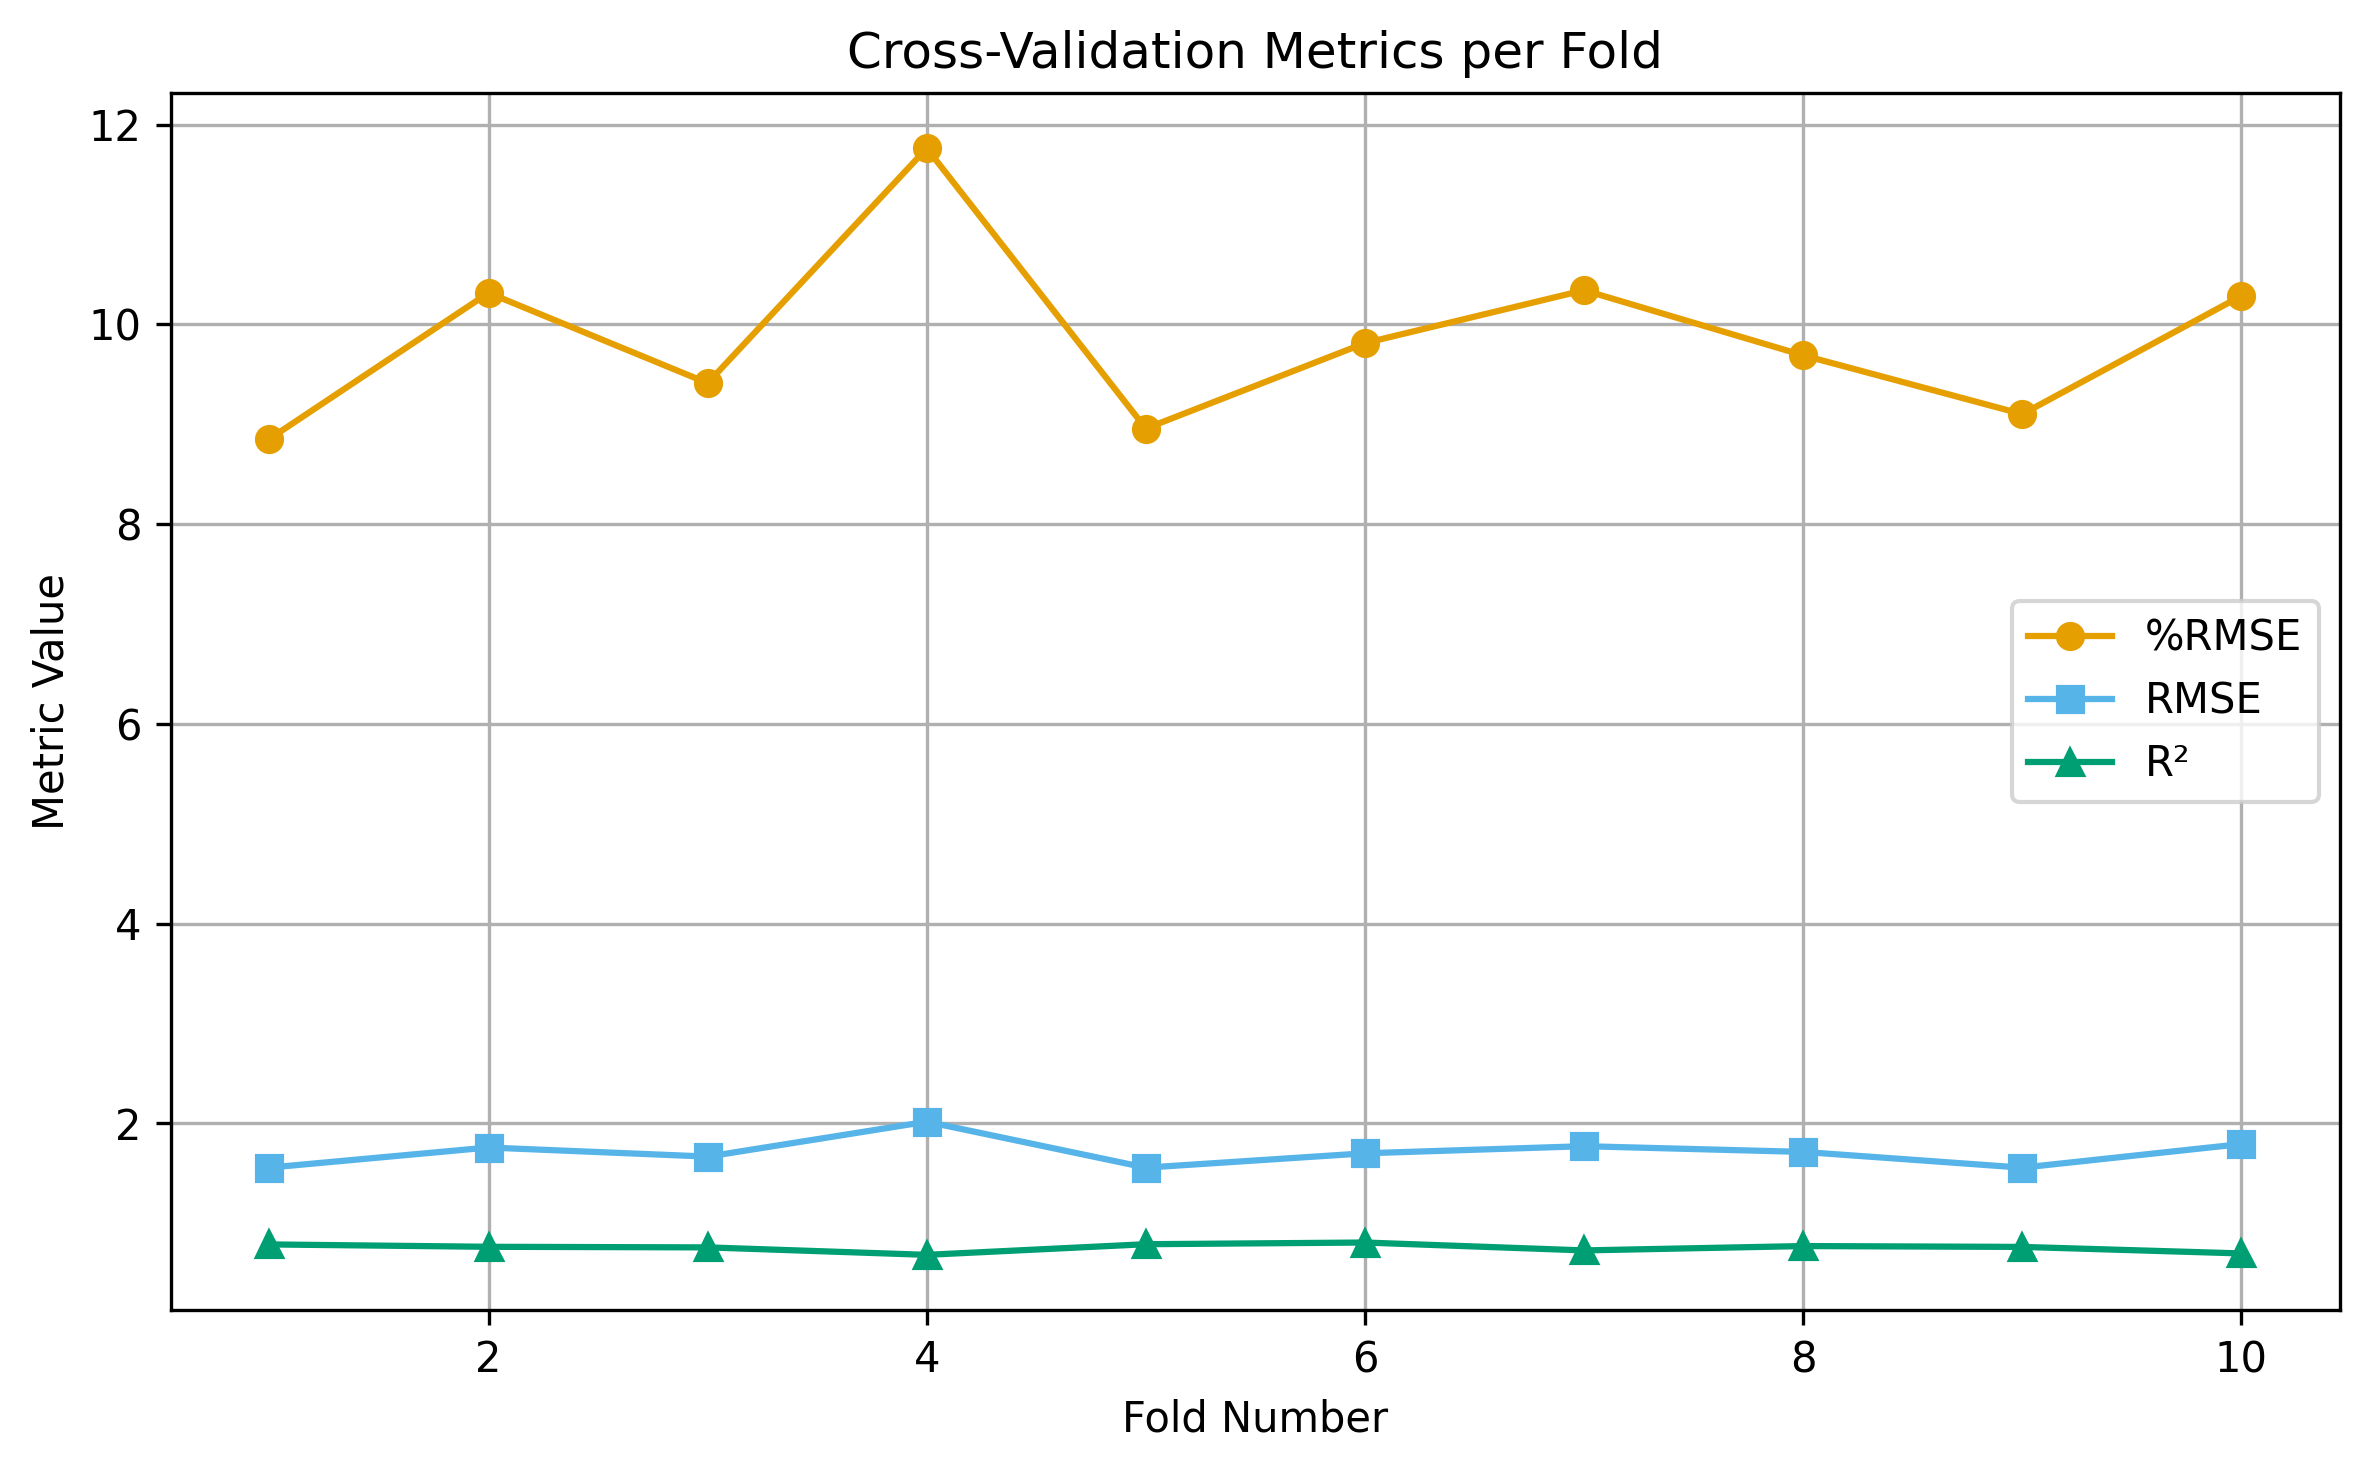

In [114]:
only_snps = only_snps.to_numpy()
y_all = y_all.to_numpy() 
best_xgbr_model, results = eval_k_fold(best_xgbreg, only_snps, y_all, 10)

In [42]:
#pickle.dump(best_xgbr_model, open("gene_pav_afterFS_varthreshold.pickle.dat", "wb"))
best_xgbr_model = pickle.load(open("best_models/gene_pav_afterFS_varthreshold.pickle.dat", "rb"))

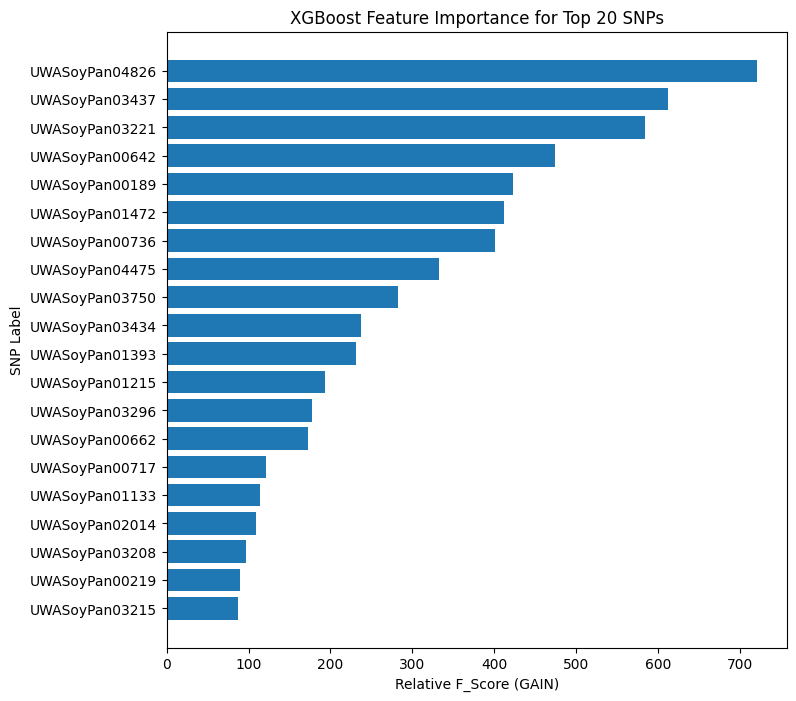

In [43]:
feature_importance= plot_xgb_feature_importance(best_xgbr_model, only_snps_dupe , top_n=20, savepath="PAV_vt_so_FI.png")

In [44]:
explainer = shap.Explainer(best_xgbr_model)

In [45]:
print(only_snps_dupe.shape)
print(best_xgbr_model.n_features_in_)

(1144, 2951)
2951


In [46]:
shap_values = explainer(only_snps_dupe, check_additivity=False)

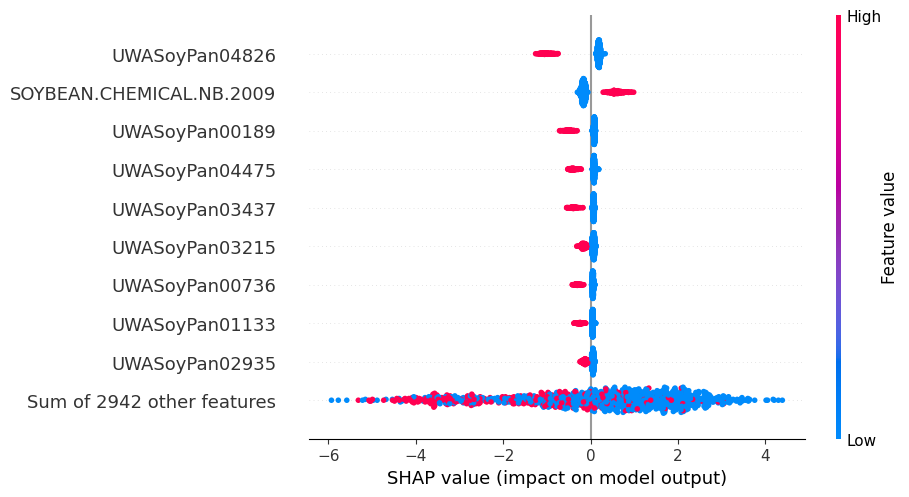

In [47]:
shap.plots.beeswarm(shap_values,show=False)
plt.savefig('PAV_vt_so_shap.png', dpi=600, bbox_inches='tight')

In [121]:
holdout_data = pd.read_pickle("gene_pav_afterFS_varthreshold_holdout_data_pav.pkl")
holdout_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
new_line,,,,,,,,,,,,,,,,,,,,,
HN009_SOYBEAN.EVALUATION.5IL90,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,16.8
HN010_SOYBEAN.EVALUATION.4IL87,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015_SOYBEAN.EVALUATION.3IL83.2,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.0
HN017B_SOYBEAN.EVALUATION.3IL83.2,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023_SOYBEAN.EVALUATION.2IL81.2,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.6


In [122]:
holdout_data['Data-storage-ID'] = holdout_data.index.to_series().str.split('_').str[0]
#fs_data['Line'] = fs_data.index.str.split('_').str[0]
holdout_data = holdout_data.reset_index(drop=True).set_index('Data-storage-ID')
holdout_data.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85,seed_oil
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,16.8
HN010,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,18.3
HN015,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.0
HN017B,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,15.5
HN023,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,15.6


In [123]:
X_holdout = holdout_data.iloc[:, 0:2951]
X_holdout.head()

,GlymaLee.01G000100.1.v1.1,GlymaLee.01G030900.1.v1.1,GlymaLee.01G034000.1.v1.1,GlymaLee.01G044800.1.v1.1,GlymaLee.01G044900.1.v1.1,GlymaLee.01G072000.1.v1.1,GlymaLee.01G073900.1.v1.1,GlymaLee.01G074000.1.v1.1,GlymaLee.01G076200.1.v1.1,GlymaLee.01G085600.1.v1.1,...,SOYBEAN.EVALUATION.MS1999_01,SOYBEAN.EVALUATION.MS2000_02,SOYBEAN.EVALUATION.MS2001_02,SOYBEAN.EVALUATION.MS2001_03,SOYBEAN.EVALUATION.MS923,SOYBEAN.EVALUATION.MS945,SOYBEAN.EVALUATION.MS967,SOYBEAN.EVALUATION.MS989,SOYBEAN.GENERAL,WILD.SOYBEAN.EVAL.1IL85
Data-storage-ID,,,,,,,,,,,,,,,,,,,,,
HN009,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN010,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
HN015,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
HN017B,1,0,1,1,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
HN023,1,0,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [124]:
y_holdout = holdout_data.iloc[:, 2951:]
y_holdout.head()

,seed_oil
Data-storage-ID,
HN009,16.8
HN010,18.3
HN015,15.0
HN017B,15.5
HN023,15.6


In [125]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [126]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128 entries, HN009 to USB-803
Columns: 2951 entries, GlymaLee.01G000100.1.v1.1 to WILD.SOYBEAN.EVAL.1IL85
dtypes: int64(33), object(2918)
memory usage: 2.9+ MB


In [127]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

R^2 Value of Holdout: 0.85
RMSE of Holdout: 1.44
Mean of Holdout: 16.91
This is 8.54% of the mean pheno data
0 16.8 18.548227
1 18.3 16.925474
2 15.0 15.839879
3 15.5 16.463003
4 15.6 16.810421


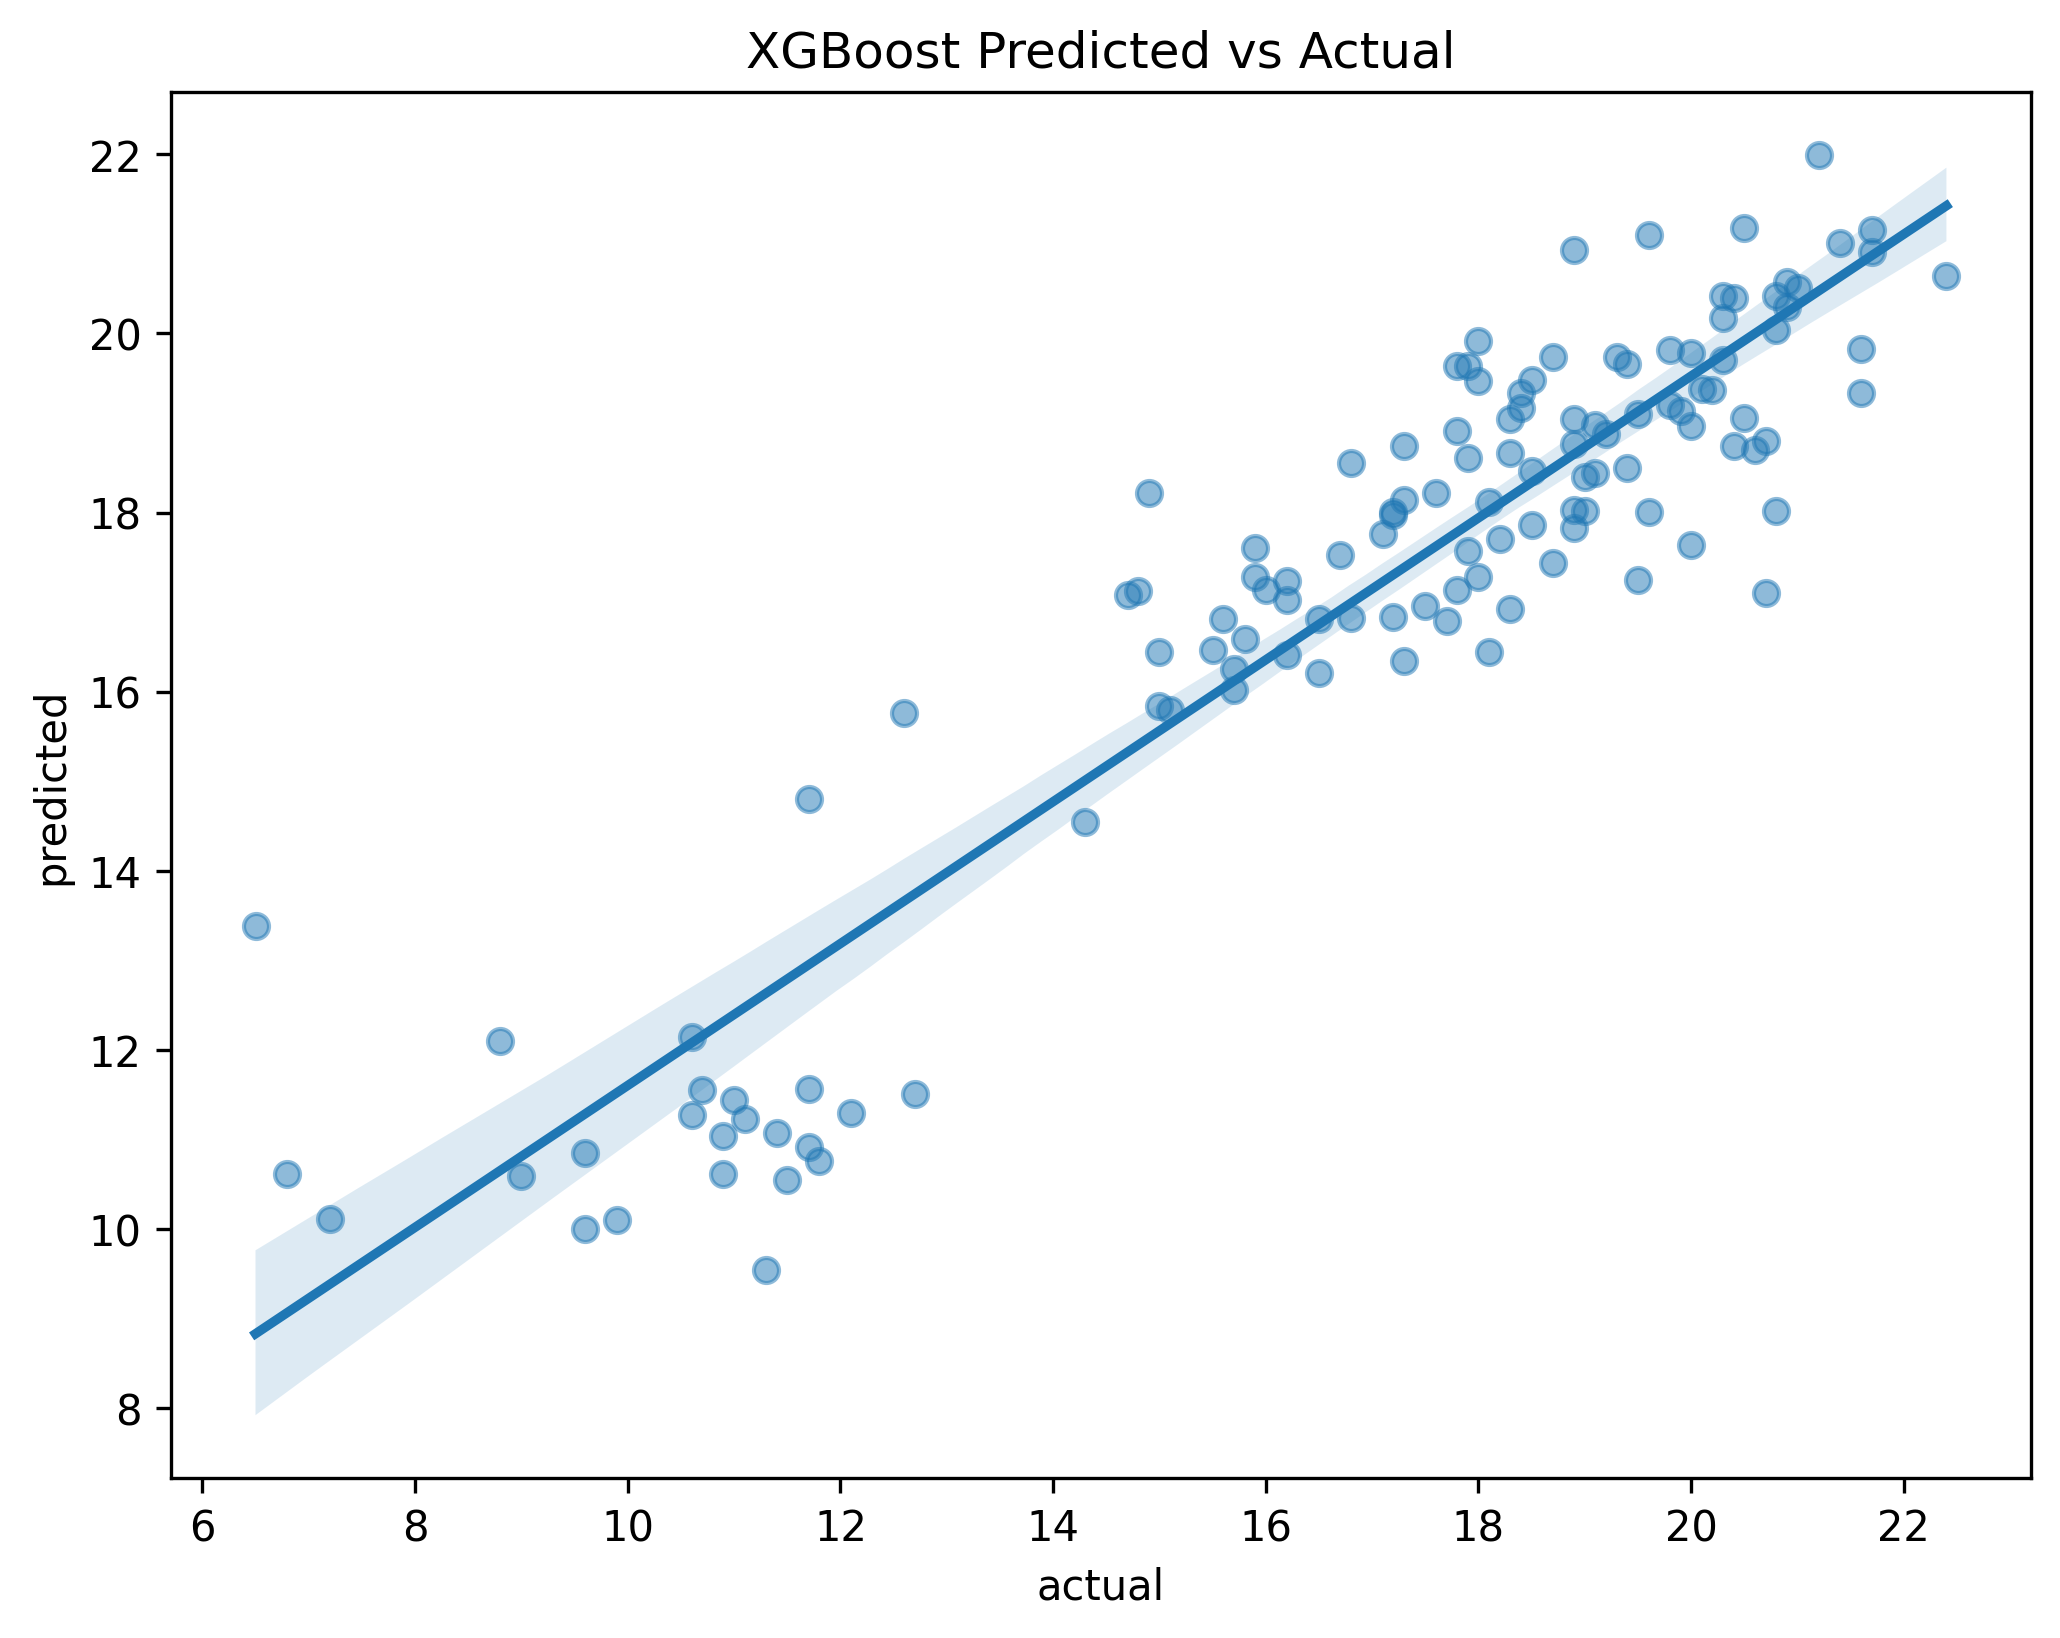

In [128]:
metrics = evaluate_holdout_performance(best_xgbr_model, X_holdout, y_holdout)